In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Carga de datos

En el notebook anterior guardamos nuestros datos limpios en el directorio clean/ . Carguemos estos datos a DataFrames.

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')

In [3]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
373,0,1,male,22.0,0,0,135.6333,C
497,0,3,male,NaN,0,0,15.1000,S
486,1,1,female,35.0,1,0,90.0000,S
756,0,3,male,28.0,0,0,7.7958,S


In [4]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Veamos estos mismos datos en una gráfica

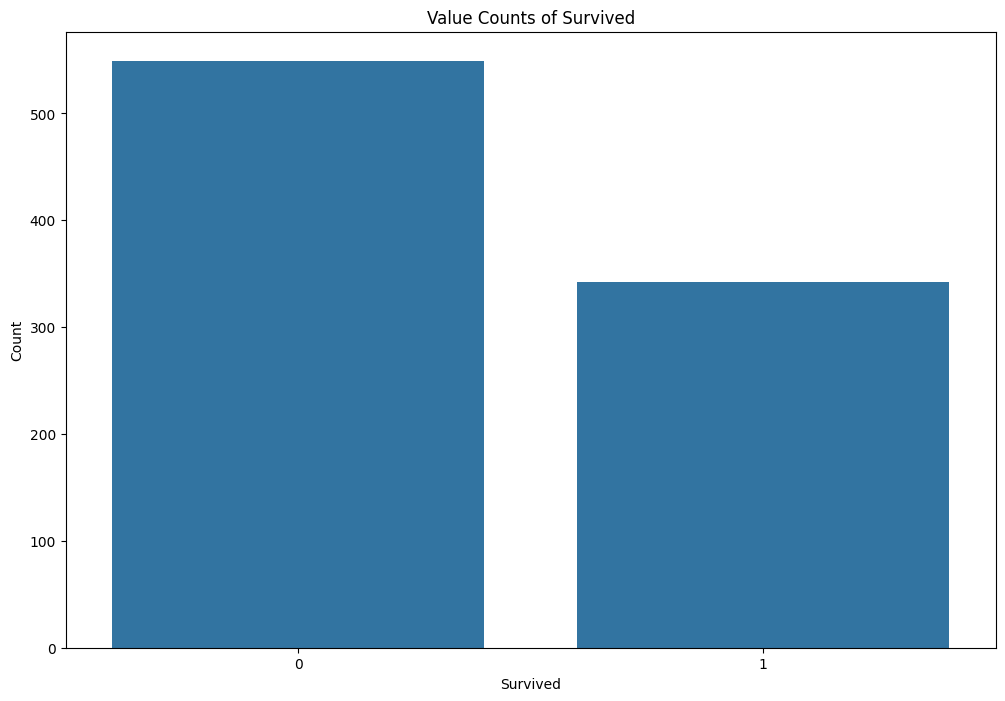

In [5]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

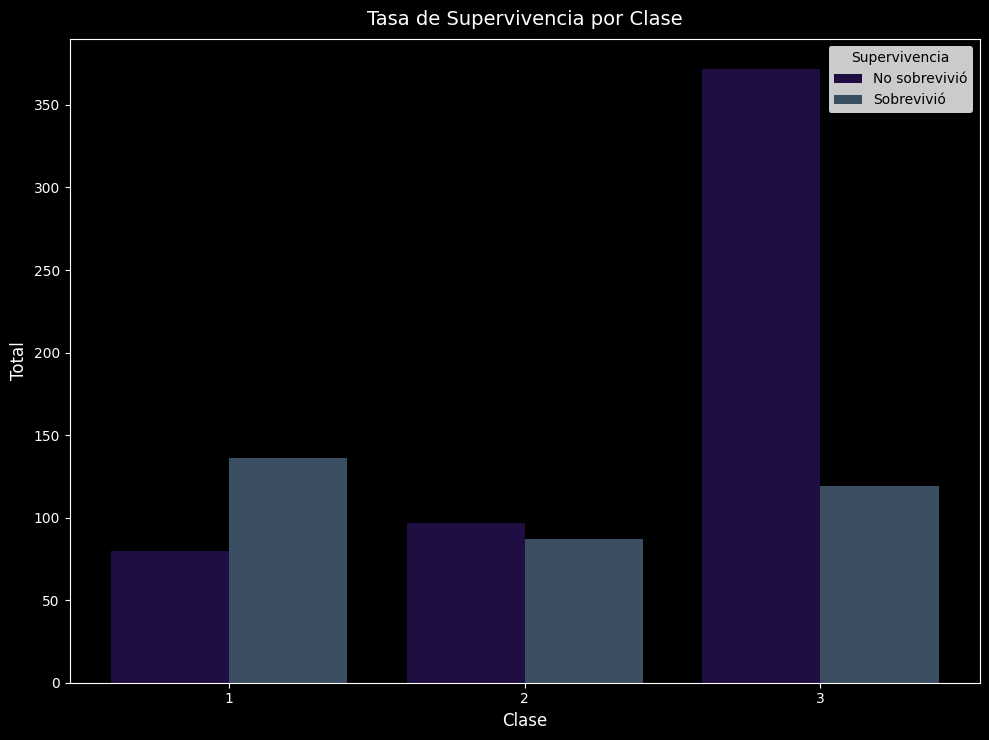

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definición de los datos extraídos de la gráfica
clases = ['1', '2', '3']
no_sobrevivio = [80, 97, 372]  # Valores aproximados del eje Y
sobrevivio = [136, 87, 119]

x = np.arange(len(clases))  # Localización de las etiquetas en el eje X
ancho_barra = 0.40          # Ancho de cada barra individual

# 2. Configurar el estilo visual oscuro (opcional, para igualar el fondo de la imagen original)
plt.style.use('dark_background')  # Elimina esta línea si prefieres fondo blanco estándar

# 3. Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(10, 7.5))

# 4. Dibujar las barras con los colores de la gráfica original
# Color morado muy oscuro para 'No sobrevivió' y gris azulado para 'Sobrevivió'
barras_no = ax.bar(x - ancho_barra/2, no_sobrevivio, ancho_barra, label='No sobrevivió', color='#1f0e42')
barras_si = ax.bar(x + ancho_barra/2, sobrevivio, ancho_barra, label='Sobrevivió', color='#3b4d61')

# 5. Personalización de etiquetas, títulos y ejes
ax.set_title('Tasa de Supervivencia por Clase', fontsize=14, pad=10)
ax.set_xlabel('Clase', fontsize=12)
ax.set_ylabel('Total', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.set_ylim(0, 390)  # Límite superior del eje Y para que coincida

# 6. Añadir y configurar la leyenda corporativa
ax.legend(title='Supervivencia', loc='upper right', frameon=True, facecolor='white', edgecolor='none', labelcolor='black')
plt.setp(ax.get_legend().get_title(), color='black')  # Texto del título de la leyenda en negro

# Ajustar márgenes automáticos para que no se corte el contenido
plt.tight_layout()

# 7. Mostrar la gráfica en pantalla
plt.show()


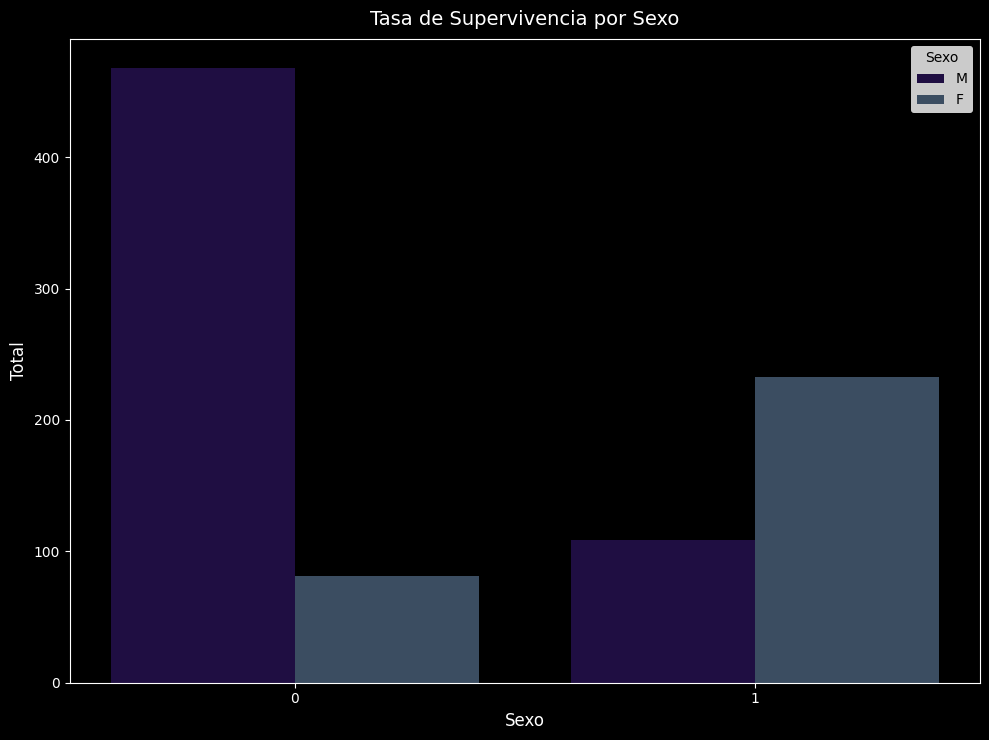

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definición de los datos aproximados de la gráfica
sexo = ['0', '1']
masculino = [468, 109]  # Valores aproximados del eje Y para 'M'
femenino = [81, 233]    # Valores aproximados del eje Y para 'F'

x = np.arange(len(sexo))  # Localización de las etiquetas en el eje X
ancho_barra = 0.40        # Ancho de cada barra individual

# 2. Configurar el estilo visual oscuro de fondo (ajustado a la imagen)
plt.style.use('dark_background')

# 3. Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(10, 7.5))

# 4. Dibujar las barras con la paleta de colores original
# Color morado muy oscuro para 'M' y gris azulado para 'F'
barras_m = ax.bar(x - ancho_barra/2, masculino, ancho_barra, label='M', color='#1f0e42')
barras_f = ax.bar(x + ancho_barra/2, femenino, ancho_barra, label='F', color='#3b4d61')

# 5. Personalización de etiquetas, títulos y ejes
ax.set_title('Tasa de Supervivencia por Sexo', fontsize=14, pad=10)
ax.set_xlabel('Sexo', fontsize=12)
ax.set_ylabel('Total', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(sexo)
ax.set_ylim(0, 490)  # Límite superior del eje Y para que coincida

# 6. Añadir y configurar la leyenda corporativa en la esquina superior derecha
ax.legend(title='Sexo', loc='upper right', frameon=True, facecolor='white', edgecolor='none', labelcolor='black')
plt.setp(ax.get_legend().get_title(), color='black')  # Texto del título de la leyenda en negro

# Ajustar márgenes automáticos
plt.tight_layout()

# 7. Mostrar la gráfica en pantalla
plt.show()


Survived y Embarked

Finalmente, veamos la tasa de supervivencia por puerto de embarque

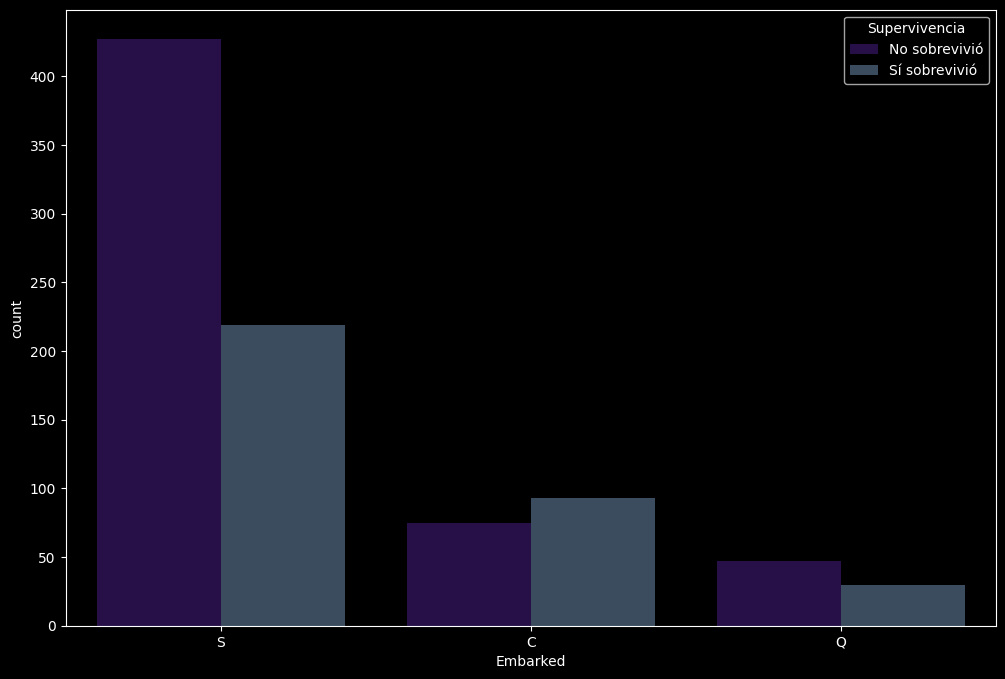

In [8]:
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

Age

Veamos la distribución de las edades

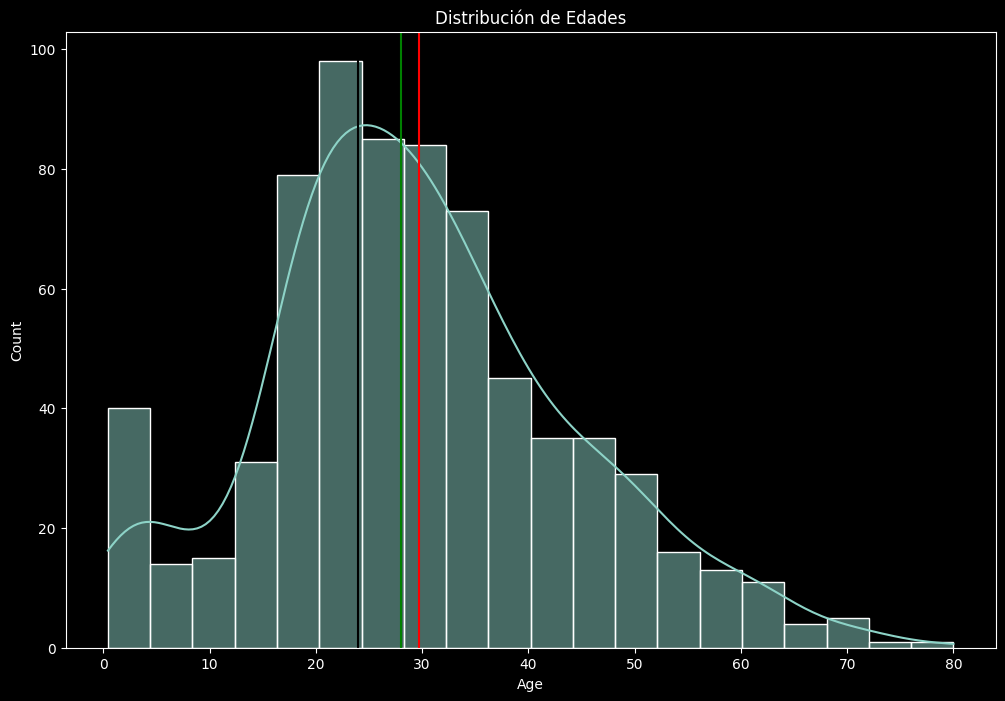

Media: 29.69911764705882
Mediana: 28.0
Moda: 24.0


In [9]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

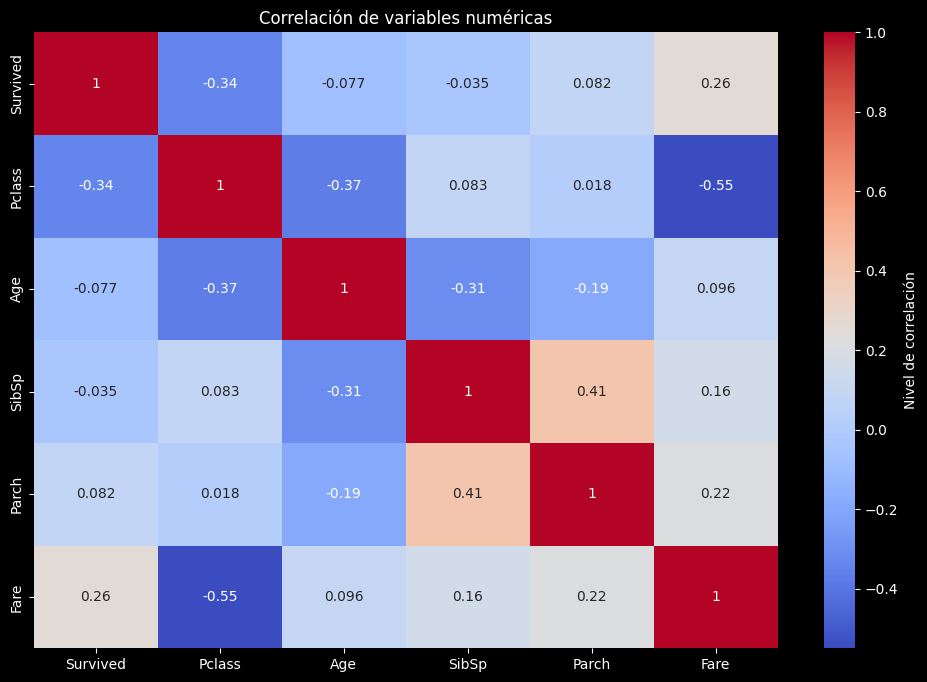

In [10]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

Crea una gráfica que muestre la distribución de edades de los pasajeros.

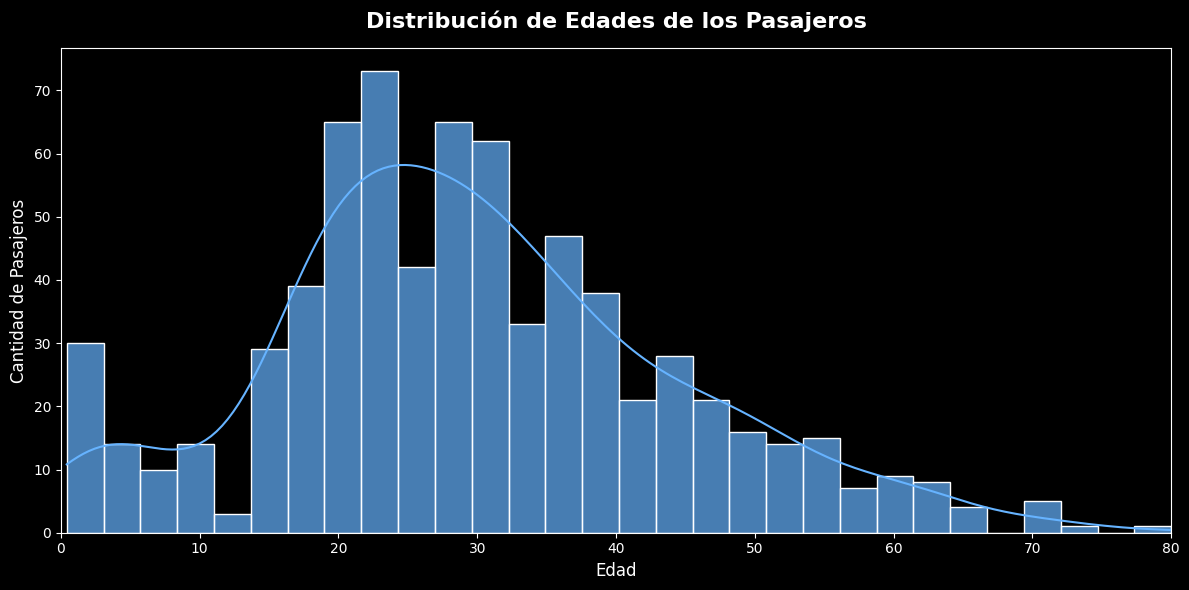

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo visual oscuro (opcional, para mantener la estética previa)
plt.style.use('dark_background')

# 2. Crear la figura y el lienzo
plt.figure(figsize=(12, 6))

# 3. Crear el histograma con curva de densidad (KDE)
# Nota: 'kde=True' dibuja la línea de tendencia suave sobre las barras.
# 'bins=30' divide las edades en 30 bloques o intervalos.
sns.histplot(data=df, x='Age', bins=30, kde=True, color='#66b3ff', edgecolor='white', alpha=0.7)

# 4. Personalización de etiquetas y títulos
plt.title('Distribución de Edades de los Pasajeros', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)

# Ajustar los límites del eje X si es necesario (ej. de 0 a 80 años)
plt.xlim(0, df['Age'].max())

# Ajustar el diseño para que no se corten los textos
plt.tight_layout()

# 5. Mostrar la gráfica
plt.show()


Crea una gráfica que muestre la cantidad de sobrevivientes por clase de pasajero (Pclass).

C:\Users\Israel\AppData\Local\Temp\ipykernel_36964\3067471059.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Israel\AppData\Local\Temp\ipykernel_36964\3067471059.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Primera Clase (1)', 'Segunda Clase (2)', 'Tercera Clase (3)'])


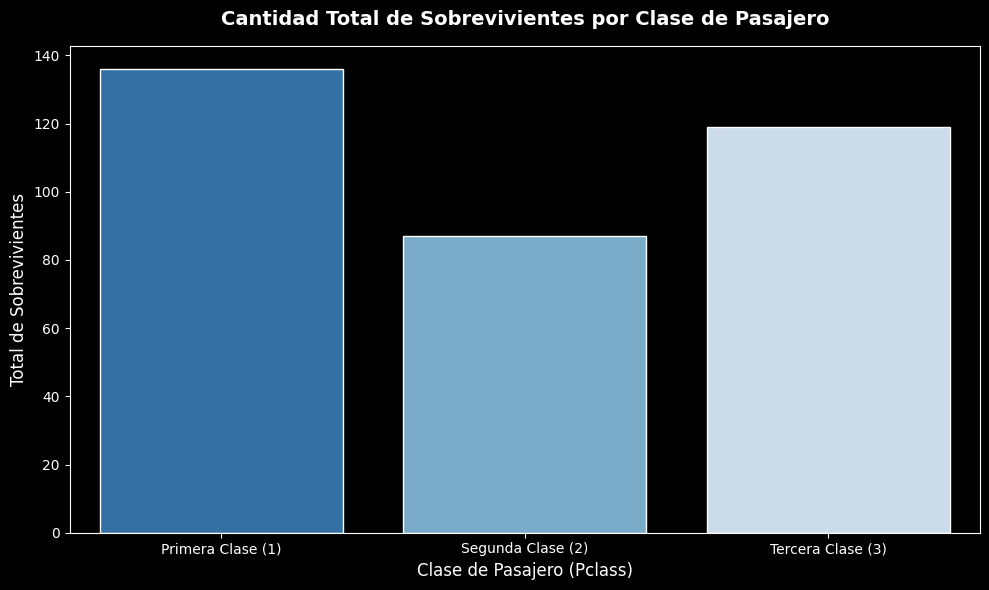

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo visual oscuro (para mantener la estética de tus gráficas)
plt.style.use('dark_background')

# 2. Filtrar el DataFrame para incluir SOLO a los supervivientes
df_sobrevivientes = df[df['Survived'] == 1]

# 3. Crear la figura y el lienzo
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Crear el gráfico de barras
# Usamos una paleta de colores degradada azul/grisácea uniforme
sns.countplot(
    data=df_sobrevivientes, 
    x='Pclass', 
    palette='Blues_r', 
    edgecolor='white',
    ax=ax
)

# 5. Personalización de etiquetas y títulos
ax.set_title('Cantidad Total de Sobrevivientes por Clase de Pasajero', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Clase de Pasajero (Pclass)', fontsize=12)
ax.set_ylabel('Total de Sobrevivientes', fontsize=12)

# Asegurar que el eje X muestre correctamente las clases 1, 2 y 3
ax.set_xticklabels(['Primera Clase (1)', 'Segunda Clase (2)', 'Tercera Clase (3)'])

# Ajustar márgenes automáticos
plt.tight_layout()

# 6. Mostrar la gráfica
plt.show()
